Menggunakan peranti: cuda
--- Eksperimen 1: Learning Rate = 0.01 ---
Epoch [1/5], Loss: 0.2815
Epoch [2/5], Loss: 0.2024
Epoch [3/5], Loss: 0.1919
Epoch [4/5], Loss: 0.1829
Epoch [5/5], Loss: 0.1755
Testing Accuracy: 94.68%

--- Eksperimen 2: Learning Rate = 0.001 ---
Epoch [1/5], Loss: 0.2621
Epoch [2/5], Loss: 0.1143
Epoch [3/5], Loss: 0.0799
Epoch [4/5], Loss: 0.0614
Epoch [5/5], Loss: 0.0488
Testing Accuracy: 97.67%



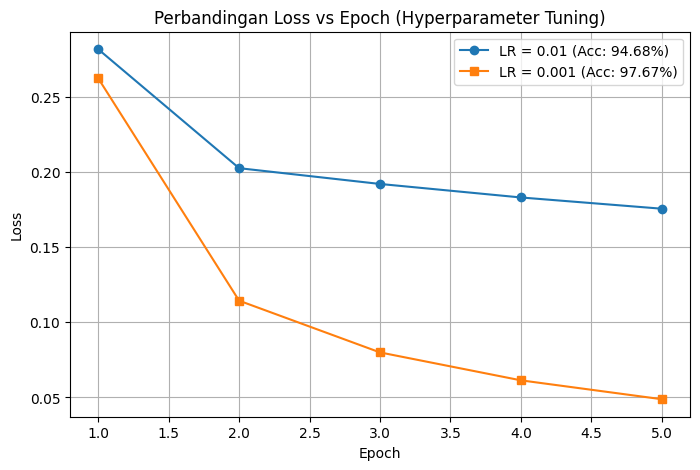

In [2]:
# ==========================================================
# 7.2.1 Import & Setup Library
# ==========================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Semak peranti (Guna GPU jika ada, jika tiada guna CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan peranti: {device}")

# ==========================================================
# 7.2.2 Load & Preprocess Dataset MNIST
# ==========================================================
# Penukaran gambar ke bentuk Tensor dan Normalisasi
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Muat turun data latihan dan data ujian MNIST
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Persediaan DataLoader untuk pembahagian batch
batch_size = 64
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

# ==========================================================
# 6.1 & 7.2.3 Pembinaan Struktur Model ANN
# ==========================================================
class SimpleANN(nn.Module):
    def __init__(self):
        super(SimpleANN, self).__init__()
        # Input Layer: 28x28 = 784 pixels -> Hidden Layer: 128 nodes
        self.fc1 = nn.Linear(28 * 28, 128)
        # Fungsi Aktivasi: ReLU
        self.relu = nn.ReLU()
        # Hidden Layer: 128 nodes -> Output Layer: 10 kelas (digit 0-9)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28) # Ratakan (flatten) imej 2D menjadi 1D vector
        x = self.fc1(x)
        x = self.relu(x)        # Penggunaan aktivasi ReLU
        x = self.fc2(x)
        return x

# ==========================================================
# 7.2.5 & 7.2.6 Fungsi Training Loop & Pengujian Accuracy
# ==========================================================
def train_and_evaluate(model, optimizer, criterion, epochs=5):
    train_losses = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()            # Reset gradien sebelumnya
            outputs = model(images)           # Forward pass
            loss = criterion(outputs, labels) # Kira nilai ralat (loss)
            loss.backward()                  # Backward pass (kira gradien)
            optimizer.step()                 # Kemas kini berat (weights)

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        train_losses.append(epoch_loss)
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}")

    # Ujian ketepatan (Testing Accuracy)
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Testing Accuracy: {accuracy:.2f}%\n")
    return train_losses, accuracy

# ==========================================================
# 6.2 & 7.2.7 Hyperparameter Tuning (Ubah Learning Rate)
# ==========================================================
# Definisi Loss Function: CrossEntropyLoss
criterion = nn.CrossEntropyLoss()

# Eksperimen 1: Learning Rate = 0.01
print("--- Eksperimen 1: Learning Rate = 0.01 ---")
model1 = SimpleANN().to(device)
optimizer1 = optim.Adam(model1.parameters(), lr=0.01) # Optimizer Adam (lr=0.01)
losses_lr1, acc1 = train_and_evaluate(model1, optimizer1, criterion, epochs=5)

# Eksperimen 2: Learning Rate = 0.001
print("--- Eksperimen 2: Learning Rate = 0.001 ---")
model2 = SimpleANN().to(device)
optimizer2 = optim.Adam(model2.parameters(), lr=0.001) # Optimizer Adam (lr=0.001)
losses_lr2, acc2 = train_and_evaluate(model2, optimizer2, criterion, epochs=5)

# ==========================================================
# 6.3 & 7.3.4 Plot Graf Perbandingan Loss vs Epoch
# ==========================================================
plt.figure(figsize=(8, 5))
plt.plot(range(1, 6), losses_lr1, label=f'LR = 0.01 (Acc: {acc1:.2f}%)', marker='o')
plt.plot(range(1, 6), losses_lr2, label=f'LR = 0.001 (Acc: {acc2:.2f}%)', marker='s')
plt.title('Perbandingan Loss vs Epoch (Hyperparameter Tuning)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()